In [79]:
import sys
import os
import pandas as pd

project_root = os.path.dirname(os.path.abspath(''))
if project_root not in sys.path:
    sys.path.append(project_root)

from MODELS.xgboostModel import *

In [80]:
pd.set_option('display.max_columns', None)

# s19 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_19.csv')
s20 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_20.csv')
s21 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_21.csv')
s22 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_22.csv')
s23 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_23.csv')
s24 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_24.csv')
s25 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_25.csv')
s26 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_26.csv')

for df in [s20, s21, s22, s23, s24, s25, s26]:
    df.sort_values(['PLAYER_ID', 'GAME_DATE'], inplace=True)
    df.reset_index(drop=True, inplace=True)
    df['GUARD_DEF_RATING_OVER_LEAGUE_AVG'] = df['GUARD'] * round(df['OPP_GUARD_DEF_RATING'] / df['LEAGUE_AVG_GUARD_DEF_RATING'], 2)
    df['FORWARD_DEF_RATING_OVER_LEAGUE_AVG'] = df['FORWARD'] * round(df['OPP_FORWARD_DEF_RATING'] / df['LEAGUE_AVG_FORWARD_DEF_RATING'], 2)
    df['CENTER_DEF_RATING_OVER_LEAGUE_AVG'] = df['CENTER'] * round(df['OPP_CENTER_DEF_RATING'] / df['LEAGUE_AVG_CENTER_DEF_RATING'], 2)
    df['POSS_VARIANCE_STABILITY'] = round(df['POSS_VOLATILITY_10_TO_DATE'] / (df['POSS_VOLATILITY_40_TO_DATE'] + 0.001), 2)
    df['MIN_CEILING_L5'] = df.groupby('PLAYER_ID')['MIN'].transform(
        lambda x: x.shift(1).rolling(window=5, min_periods=1).max().round(2))
    df['MIN_FLOOR_L5'] = df.groupby('PLAYER_ID')['MIN'].transform(
        lambda x: x.shift(1).rolling(window=5, min_periods=1).min().round(2))
    df['MIN_CEILING_L5_DELTA'] = (df['MIN_CEILING_L5'] - df['MIN_AVG_TO_DATE']).round(2)
    df['MIN_FLOOR_L5_DELTA'] = (df['MIN_FLOOR_L5'] - df['MIN_AVG_TO_DATE']).round(2)
    df['PTS_CEILING_L5'] = df.groupby('PLAYER_ID')['PTS'].transform(
        lambda x: x.shift(1).rolling(window=5, min_periods=1).max().round(2))
    df['PTS_FLOOR_L5'] = df.groupby('PLAYER_ID')['PTS'].transform(
        lambda x: x.shift(1).rolling(window=5, min_periods=1).min().round(2))
    df['PTS_CEILING_L5_DELTA'] = (df['PTS_CEILING_L5'] - df['PTS_AVG_TO_DATE']).round(2)
    df['PTS_FLOOR_L5_DELTA'] = (df['PTS_FLOOR_L5'] - df['PTS_AVG_TO_DATE']).round(2)
    df['USG_CEILING_L5'] = df.groupby('PLAYER_ID')['USG_PCT'].transform(
        lambda x: x.shift(1).rolling(window=5, min_periods=1).max().round(2))
    df['USG_FLOOR_L5'] = df.groupby('PLAYER_ID')['USG_PCT'].transform(
        lambda x: x.shift(1).rolling(window=5, min_periods=1).min().round(2))
    df['USG_CEILING_L5_DELTA'] = (df['USG_CEILING_L5'] - df['USG_PCT_AVG_TO_DATE']).round(2)
    df['USG_FLOOR_L5_DELTA'] = (df['USG_FLOOR_L5'] - df['USG_PCT_AVG_TO_DATE']).round(2)
    df['STARTING_x_MIN_AVG'] = df['STARTING'] * df['MIN_AVG_TO_DATE']
    df['STARTING_x_MIN_CEILING'] = df['STARTING'] * df['MIN_CEILING_L5']
    df['USG_PER_MIN'] = df['USG_PCT_AVG_TO_DATE'] / df['MIN_AVG_TO_DATE'] + 0.001
    df['POSS_PER_MIN'] = df['POSS_AVG_TO_DATE'] / df['MIN_AVG_TO_DATE'] + 0.001
    df['TCHS_PER_MIN'] = df['TCHS_AVG_TO_DATE'] / df['MIN_AVG_TO_DATE'] + 0.001

train_df = pd.concat([s20,s21,s22,s23,s24])
val_df = s25
test_df = s26

print("BEFORE FILTERING:")
print(f"Train set: {len(train_df)} samples")
print(f"Val set: {len(val_df)} samples")
print(f"Test set: {len(test_df)} samples")
test_df.sample()

BEFORE FILTERING:
Train set: 123809 samples
Val set: 26306 samples
Test set: 6403 samples


,Unnamed: 0,PLAYER_NAME,PLAYER_ID,MATCHUP,TEAM_ABBREVIATION,TEAM_ID,OPP_ABBREVIATION,HOME_GAME,GAME_ID,GAME_DATE,WL,PTS,AST,REB,FGM,FGA,FG_PCT,FG3M,FG3A,FG3_PCT,FTM,FTA,FT_PCT,OREB,DREB,STL,BLK_x,TOV,PLUS_MINUS,FANTASY_PTS,POINT_PER_SHOT,EFG,START_POSITION,COMMENT,OFF_RATING,E_OFF_RATING,DEF_RATING,E_DEF_RATING,NET_RATING,OREB_PCT,DREB_PCT,REB_PCT,AST_PCT,EFG_PCT,AST_TOV,USG_PCT,TS_PCT,E_PACE,PACE,PIE,POSS,PACE_PER40,E_USG_PCT,MIN,SPD,DIST,ORBC,DRBC,RBC,TCHS,SAST,FTAST,PASS,CFGM,CFGA,CFG_PCT,UFGM,UFGA,UFG_PCT,DFGM,DFGA,DFG_PCT,percentageFieldGoalsAttempted2pt,percentageFieldGoalsAttempted3pt,percentagePoints2pt,percentagePointsMidrange2pt,percentagePoints3pt,percentagePointsFastBreak,percentagePointsFreeThrow,percentagePointsOffTurnovers,percentagePointsPaint,percentageAssisted2pt,percentageUnassisted2pt,percentageAssisted3pt,percentageUnassisted3pt,percentageAssistedFGM,percentageUnassistedFGM,matchupFieldGoalsMade,matchupFieldGoalsAttempted,matchupThreePointersMade,matchupThreePointersAttempted,playerPoints,matchupMinutes,matchupFieldGoalsPercentage,matchupThreePointersPercentage,PTS_OFF_TOV,PTS_2ND_CHANCE,PTS_FB,PTS_PAINT,OPP_PTS_OFF_TOV,OPP_PTS_2ND_CHANCE,OPP_PTS_FB,OPP_PTS_PAINT,BLK_y,BLKA,PF,PFD,TEAM_SEASON_ID,TEAM_NAME,TEAM_GAME_DATE,TEAM_MATCHUP,TEAM_WL,TEAM_MIN,TEAM_FGM,TEAM_FGA,TEAM_FG_PCT,TEAM_FG3M,TEAM_FG3A,TEAM_FG3_PCT,TEAM_FTM,TEAM_FTA,TEAM_FT_PCT,TEAM_OREB,TEAM_DREB,TEAM_REB,TEAM_AST,TEAM_STL,TEAM_BLK,TEAM_TOV,TEAM_PF,TEAM_PTS,TEAM_PLUS_MINUS,VIDEO_AVAILABLE,TEAM_PACE,GAME_PACE,OPP_PACE,OPP_TEAM_ID,TEAM_OFF_RATING,TEAM_DEF_RATING,OPP_DEF_RATING,OPP_OFF_RATING,OPP_PTS,OPP_FGM,OPP_FGA,OPP_FG_PCT,OPP_REB,OPP_AST,OPP_STL,OPP_BLK,OPP_TOV,STARTING,HEIGHT,WEIGHT,GUARD,FORWARD,CENTER,TEAM_DAYS_REST,PLAYER_DAYS_REST,TEAM_B2B,IS_BACK_TO_BACK,PLAYER_MISSED_LAST,PTS_ROLLING_AVG_3,FGA_ROLLING_AVG_3,FGM_ROLLING_AVG_3,FG3A_ROLLING_AVG_3,FG3M_ROLLING_AVG_3,FTA_ROLLING_AVG_3,FTM_ROLLING_AVG_3,UFGA_ROLLING_AVG_3,UFGM_ROLLING_AVG_3,CFGA_ROLLING_AVG_3,CFGM_ROLLING_AVG_3,USG_PCT_ROLLING_AVG_3,MIN_ROLLING_AVG_3,POSS_ROLLING_AVG_3,PLUS_MINUS_ROLLING_AVG_3,TS_PCT_ROLLING_AVG_3,DIST_ROLLING_AVG_3,SPD_ROLLING_AVG_3,PF_ROLLING_AVG_3,E_OFF_RATING_ROLLING_AVG_3,NET_RATING_ROLLING_AVG_3,EFG_PCT_ROLLING_AVG_3,TCHS_ROLLING_AVG_3,FG_PCT_ROLLING_AVG_3,FG3_PCT_ROLLING_AVG_3,FT_PCT_ROLLING_AVG_3,PTS_ROLLING_AVG_5,FGA_ROLLING_AVG_5,FGM_ROLLING_AVG_5,FG3A_ROLLING_AVG_5,FG3M_ROLLING_AVG_5,FTA_ROLLING_AVG_5,FTM_ROLLING_AVG_5,UFGA_ROLLING_AVG_5,UFGM_ROLLING_AVG_5,CFGA_ROLLING_AVG_5,CFGM_ROLLING_AVG_5,USG_PCT_ROLLING_AVG_5,MIN_ROLLING_AVG_5,POSS_ROLLING_AVG_5,PLUS_MINUS_ROLLING_AVG_5,TS_PCT_ROLLING_AVG_5,DIST_ROLLING_AVG_5,SPD_ROLLING_AVG_5,PF_ROLLING_AVG_5,E_OFF_RATING_ROLLING_AVG_5,NET_RATING_ROLLING_AVG_5,EFG_PCT_ROLLING_AVG_5,TCHS_ROLLING_AVG_5,FG_PCT_ROLLING_AVG_5,FG3_PCT_ROLLING_AVG_5,FT_PCT_ROLLING_AVG_5,PTS_ROLLING_AVG_7,FGA_ROLLING_AVG_7,FGM_ROLLING_AVG_7,FG3A_ROLLING_AVG_7,FG3M_ROLLING_AVG_7,FTA_ROLLING_AVG_7,FTM_ROLLING_AVG_7,UFGA_ROLLING_AVG_7,UFGM_ROLLING_AVG_7,CFGA_ROLLING_AVG_7,CFGM_ROLLING_AVG_7,USG_PCT_ROLLING_AVG_7,MIN_ROLLING_AVG_7,POSS_ROLLING_AVG_7,PLUS_MINUS_ROLLING_AVG_7,TS_PCT_ROLLING_AVG_7,DIST_ROLLING_AVG_7,SPD_ROLLING_AVG_7,PF_ROLLING_AVG_7,E_OFF_RATING_ROLLING_AVG_7,NET_RATING_ROLLING_AVG_7,EFG_PCT_ROLLING_AVG_7,TCHS_ROLLING_AVG_7,FG_PCT_ROLLING_AVG_7,FG3_PCT_ROLLING_AVG_7,FT_PCT_ROLLING_AVG_7,PTS_ROLLING_AVG_10,FGA_ROLLING_AVG_10,FGM_ROLLING_AVG_10,FG3A_ROLLING_AVG_10,FG3M_ROLLING_AVG_10,FTA_ROLLING_AVG_10,FTM_ROLLING_AVG_10,UFGA_ROLLING_AVG_10,UFGM_ROLLING_AVG_10,CFGA_ROLLING_AVG_10,CFGM_ROLLING_AVG_10,USG_PCT_ROLLING_AVG_10,MIN_ROLLING_AVG_10,POSS_ROLLING_AVG_10,PLUS_MINUS_ROLLING_AVG_10,TS_PCT_ROLLING_AVG_10,DIST_ROLLING_AVG_10,SPD_ROLLING_AVG_10,PF_ROLLING_AVG_10,E_OFF_RATING_ROLLING_AVG_10,NET_RATING_ROLLING_AVG_10,EFG_PCT_ROLLING_AVG_10,TCHS_ROLLING_AVG_10,FG_PCT_ROLLING_AVG_10,FG3_PCT_ROLLING_AVG_10,FT_PCT_ROLLING_AVG_10,PTS_ROLLING_AVG_20,FGA_ROLLING_AVG_20,FGM_ROLLING_AVG_20,FG3A_ROLLING_AVG_20,FG3M_ROLLING_AVG_20,F

In [81]:
player_season_avg = train_df.groupby('PLAYER_ID').agg({
    'MIN': 'mean',
    'PTS': 'mean',
    'GAMES_PLAYED_TO_DATE': 'max'
}).reset_index()

player_season_avg.columns = ['PLAYER_ID', 'MIN_AVG', 'PTS_AVG', 'GAMES_PLAYED']

# Define criteria for "relevant players"
relevant_players = player_season_avg[
    (player_season_avg['MIN_AVG'] >= 12) &      
    (player_season_avg['GAMES_PLAYED'] >= 8)
]['PLAYER_ID']

# Filter training data to only relevant players
train_df = train_df[train_df['PLAYER_ID'].isin(relevant_players)]
train_df = train_df[
    (train_df['PTS'] <= 45) &  
    (train_df['MIN'] >= 8) &
    (train_df['MIN'] <= 40) &
    (train_df['USG_PCT'] <= 0.4)    
]
train_df = train_df.dropna(subset=['PTS_ROLLING_AVG_3'])

val_df = val_df[val_df['PLAYER_ID'].isin(relevant_players)]
val_df = val_df[
    (val_df['PTS'] <= 45) &  
    (val_df['MIN'] >= 8) &
    (val_df['MIN'] <= 40) &
    (val_df['USG_PCT'] <= 0.4)    
]
val_df = val_df.dropna(subset=['PTS_ROLLING_AVG_3'])

test_df = test_df[test_df['PLAYER_ID'].isin(relevant_players)]
test_df = test_df[
    (test_df['PTS'] <= 45) &  
    (test_df['MIN'] >= 8) &
    (test_df['MIN'] <= 40) &
    (test_df['USG_PCT'] <= 0.4)    
]
test_df = test_df.dropna(subset=['PTS_ROLLING_AVG_3'])

print("AFTER FILTERING:")
print(f"Train set: {len(train_df)} samples")
print(f"Val set: {len(val_df)} samples")
print(f"Test set: {len(test_df)} samples")

AFTER FILTERING:
Train set: 98711 samples
Val set: 17732 samples
Test set: 3683 samples


In [82]:
USG_features = [
    # Player context
    'STARTING', 
    'GAMES_PLAYED_TO_DATE', 
    'LINEUP_FGA_SHARE_AVG', 
    'USG_PCT_AVG_TO_DATE', 
    'USG_PER_MIN'
]
USG_target = 'USG_PCT'
print(f"len(USG_features): {len(USG_features)}")
"""
# ADD THESE:
ON_OFF_STAR_PG
ON_OFF_PRIMARY_SCORER
ON_OFF_SECOND_CREATOR
LINEUP_USG_SHARE_AVG
LINEUP_FGA_SHARE_AVG
EXPECTED_TOUCHES
PRIMARY_HANDLER_RATE
MATCHUP_DOUBLE_TEAM_RATE
MATCHUP_PNR_COVERAGE
"""

len(USG_features): 5


'\n# ADD THESE:\nON_OFF_STAR_PG\nON_OFF_PRIMARY_SCORER\nON_OFF_SECOND_CREATOR\nLINEUP_USG_SHARE_AVG\nLINEUP_FGA_SHARE_AVG\nEXPECTED_TOUCHES\nPRIMARY_HANDLER_RATE\nMATCHUP_DOUBLE_TEAM_RATE\nMATCHUP_PNR_COVERAGE\n'

In [83]:
MIN_features = [
    # Player info
    'STARTING',
    'IS_BACK_TO_BACK',
    'PLAYER_DAYS_REST',
    'USUAL_STARTERS_AVAILABLE',
    'GAMES_PLAYED_TO_DATE',
    'MIN_CEILING_L5_DELTA', #new
    'MIN_FLOOR_L5_DELTA', #new
    'STARTING_x_MIN_AVG', #new
    'STARTING_x_MIN_CEILING', #new

    # Baseline minute distribution
    'MIN_AVG_TO_DATE',
    'MIN_L5_OVER_BASELINE',
    'MIN_L7_OVER_BASELINE',
    'MIN_L10_OVER_BASELINE',
    'MIN_STD_5_TO_DATE',
    'MIN_STD_10_TO_DATE',
    'MIN_BOOST_STAR_OUT',

    # Matchup & location expectational
    'MIN_EXPECTATION_LOCATION',
    'MATCHUP_MIN_DELTA',

    # Team context – keep only strongest predictors
    'TEAM_PACE_OVER_LEAGUE_AVG',
    'EXPECTED_PACE',

    # Opponent effects
    'OPP_DEF_RATING_OVER_LEAGUE_AVG',
    'OPP_PACE_OVER_LEAGUE_AVG',
]
MIN_target = 'MIN'
print(f"len(MIN_features): {len(MIN_features)}")
"""
# ADD:
AVAILABLE_GUARDS
AVAILABLE_WINGS
AVAILABLE_BIGS
OUT_SAME_POSITION_COUNT     # massive improvement

TEAM_ROTATION_STD
COACH_ROTATION_TIGHTNESS

SPREAD                      # blowout indicator
BLOWOUT_RISK
TRAVEL_DISTANCE_LAST_3_DAYS
REST_DAYS_TEAM_AVG
"""

len(MIN_features): 22


'\n# ADD:\nAVAILABLE_GUARDS\nAVAILABLE_WINGS\nAVAILABLE_BIGS\nOUT_SAME_POSITION_COUNT     # massive improvement\n\nTEAM_ROTATION_STD\nCOACH_ROTATION_TIGHTNESS\n\nSPREAD                      # blowout indicator\nBLOWOUT_RISK\nTRAVEL_DISTANCE_LAST_3_DAYS\nREST_DAYS_TEAM_AVG\n'

In [84]:
PTS_features = [
    # Basic context
    'STARTING',
    'GAMES_PLAYED_TO_DATE',
    'PTS_CEILING_L5_DELTA', #new
    'PTS_FLOOR_L5_DELTA', #new

    # Volume indicators
    'PTS_AVG_TO_DATE',
    'PTS_L5_OVER_BASELINE',
    'PTS_L10_OVER_BASELINE',

    'FGA_AVG_TO_DATE',
    'FGA_L5_OVER_BASELINE',
    'FGA_L10_OVER_BASELINE',

    'FTA_AVG_TO_DATE',
    'FTA_L5_OVER_BASELINE',
    'FTA_L10_OVER_BASELINE',

    'FG3A_AVG_TO_DATE',
    'FG3A_L5_OVER_BASELINE',
    'FG3A_L10_OVER_BASELINE',
    
    'PLUS_MINUS_AVG_TO_DATE',
    'PLUS_MINUS_L5_OVER_BASELINE',
    'PLUS_MINUS_L10_OVER_BASELINE',

    # Efficiency  <--- new
    'FG_PCT_AVG_TO_DATE',
    'FG_PCT_L5_OVER_BASELINE',
    'FG_PCT_L10_OVER_BASELINE',
    'FG_PCT_BOOST_STAR_OUT',
    'FG_PCT_EXPECTATION_LOCATION',
    'MATCHUP_FG_PCT_DELTA',

    'FG3_PCT_AVG_TO_DATE',
    'FG3_PCT_L5_OVER_BASELINE',
    'FG3_PCT_L10_OVER_BASELINE',
    'FG3_PCT_BOOST_STAR_OUT',
    'FG3_PCT_EXPECTATION_LOCATION',
    'MATCHUP_FG3_PCT_DELTA',

    'FT_PCT_AVG_TO_DATE',
    'FT_PCT_L5_OVER_BASELINE',
    'FT_PCT_L10_OVER_BASELINE',
    'FT_PCT_BOOST_STAR_OUT',
    'FT_PCT_EXPECTATION_LOCATION',
    'MATCHUP_FT_PCT_DELTA',

    'TS_PCT_AVG_TO_DATE',
    'TS_PCT_L5_OVER_BASELINE',

    # Variability
    'PTS_STD_5_TO_DATE',
    'PTS_BOOST_STAR_OUT',
    'PTS_EXPECTATION_LOCATION',
    'MATCHUP_PTS_DELTA',

    'FGA_STD_5_TO_DATE',
    'FGA_BOOST_STAR_OUT',
    'FGA_EXPECTATION_LOCATION',
    'MATCHUP_FGA_DELTA',

    'FG3A_STD_5_TO_DATE',
    'FG3A_BOOST_STAR_OUT',
    'FG3A_EXPECTATION_LOCATION',
    'MATCHUP_FG3A_DELTA',

    'FTA_STD_5_TO_DATE',
    'FTA_BOOST_STAR_OUT',
    'FTA_EXPECTATION_LOCATION',
    'MATCHUP_FTA_DELTA',

    'TS_PCT_STD_5_TO_DATE',
    'TS_PCT_BOOST_STAR_OUT',
    'MATCHUP_TS_PCT_DELTA',

    # Team/Opponent context
    'TEAM_OFF_RATING_OVER_LEAGUE_AVG',
    'TEAM_PACE_OVER_LEAGUE_AVG',
    'EXPECTED_PACE',
    'OPP_DEF_RATING_OVER_LEAGUE_AVG',
    'OPP_PACE_OVER_LEAGUE_AVG',

    # Positional defense
    'GUARD_DEF_RATING_OVER_LEAGUE_AVG',
    'FORWARD_DEF_RATING_OVER_LEAGUE_AVG',
    'CENTER_DEF_RATING_OVER_LEAGUE_AVG',
]
PTS_target = 'PTS'
print(f"len(PTS_features): {len(PTS_features)}")
"""
# ADD — derived from upstream models:
PRED_MIN
PRED_USG

# Add true shot quality (huge improvement)
EXPECTED_EFG
SHOT_QUALITY
RIM_FREQUENCY
MIDRANGE_FREQUENCY
CORNER_3_FREQUENCY

# Add matchup shot profile allowed:
MATCHUP_RIM_DEFENSE
MATCHUP_MIDRANGE_DEFENSE
MATCHUP_3PT_DEFENSE
MATCHUP_FOUL_RATE
"""



len(PTS_features): 66


'\n# ADD — derived from upstream models:\nPRED_MIN\nPRED_USG\n\n# Add true shot quality (huge improvement)\nEXPECTED_EFG\nSHOT_QUALITY\nRIM_FREQUENCY\nMIDRANGE_FREQUENCY\nCORNER_3_FREQUENCY\n\n# Add matchup shot profile allowed:\nMATCHUP_RIM_DEFENSE\nMATCHUP_MIDRANGE_DEFENSE\nMATCHUP_3PT_DEFENSE\nMATCHUP_FOUL_RATE\n'

In [85]:
# Train cascading model: MIN -> USG_PCT -> PTS
cascading_models = train_cascading_model(
    train_data=train_df,
    val_data=val_df,
    min_features=MIN_features,
    usg_features=USG_features,
    pts_features=PTS_features,
    date_column='GAME_DATE',
    player_column='PLAYER_ID'
)

# Extract models and metrics
min_model = cascading_models['min_model']
usg_model = cascading_models['usg_model']
pts_model = cascading_models['pts_model']
metrics = cascading_models['metrics']

print("\n" + "="*70)
print("CASCADING MODEL SUMMARY")
print("="*70)
print(f"\nMIN Model - R²: {metrics['MIN']['R2']:.3f}, RMSE: {metrics['MIN']['RMSE']:.3f}")
print(f"USG_PCT Model - R²: {metrics['USG_PCT']['R2']:.3f}, RMSE: {metrics['USG_PCT']['RMSE']:.3f}")
print(f"PTS Model - R²: {metrics['PTS']['R2']:.3f}, RMSE: {metrics['PTS']['RMSE']:.3f}")



TRAINING CASCADING MODEL: MIN -> USG_PCT -> PTS

STEP 1: Training MIN Model

TRAINING XGBOOST MODEL

📅 Step 1: Sorting by date...
   Training: 2019-10-24 to 2024-04-14
   Validation: 2024-10-24 to 2025-04-13

🧹 Step 2: Removing rows with missing target...
   Training samples: 98711
   Validation samples: 17732

📊 Step 3: Preparing features...

🔧 Step 4: Handling NaN values in features...
   • Filled 14184 NaN in training features
   • Filled 2466 NaN in validation features
   • Remaining NaN: 0

⚖️  Step 5: Creating sample weights...
   ✓ Applied 3x weight to last 15 games per player

🤖 Step 6: Training XGBoost...
   ✓ Training stopped at iteration 621

📈 Step 7: Evaluating on validation...

   VALIDATION METRICS:
   • RMSE: 5.150
   • MAE:  4.049
   • R²:   0.592

   Predictions: min=12.15, max=35.70, mean=25.88
   Actual:      min=8.00, max=40.00, mean=25.95

🔄 Step 8: Retraining on combined data...
   ✓ Final model trained on 116443 games

✅ TRAINING COMPLETE!


📊 Predicting MIN fo

In [86]:
# Make predictions on test set using cascading approach
test_predictions = predict_cascading(
    models_dict=cascading_models,
    test_data=test_df,
    min_features=MIN_features,
    usg_features=USG_features,
    pts_features=PTS_features
)

# Evaluate on test set
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

print("TEST SET EVALUATION:")
print("="*70)
for target in ['MIN', 'USG_PCT', 'PTS']:
    actual = test_df[target].values
    pred = test_predictions[target]
    
    rmse = np.sqrt(mean_squared_error(actual, pred))
    mae = mean_absolute_error(actual, pred)
    r2 = r2_score(actual, pred)
    
    print(f"\n{target}:")
    print(f"  RMSE: {rmse:.3f}")
    print(f"  MAE:  {mae:.3f}")
    print(f"  R²:   {r2:.3f}")
    print(f"  Predictions: min={pred.min():.2f}, max={pred.max():.2f}, mean={pred.mean():.2f}")
    print(f"  Actual:       min={actual.min():.2f}, max={actual.max():.2f}, mean={actual.mean():.2f}")


TEST SET EVALUATION:

MIN:
  RMSE: 5.045
  MAE:  3.947
  R²:   0.600
  Predictions: min=12.52, max=35.38, mean=25.86
  Actual:       min=8.05, max=39.98, mean=25.90

USG_PCT:
  RMSE: 0.053
  MAE:  0.041
  R²:   0.481
  Predictions: min=0.11, max=0.30, mean=0.19
  Actual:       min=0.00, max=0.40, mean=0.19

PTS:
  RMSE: 6.127
  MAE:  4.724
  R²:   0.493
  Predictions: min=2.21, max=32.25, mean=12.35
  Actual:       min=0.00, max=44.00, mean=12.94


In [87]:
import joblib

# Save the models
joblib.dump(min_model, 'SAVED_MODELS/min_model.pkl')
joblib.dump(MIN_features, 'SAVED_MODELS/min_features.pkl')
joblib.dump(usg_model, 'SAVED_MODELS/usg_model.pkl')
joblib.dump(USG_features, 'SAVED_MODELS/usg_features.pkl')
joblib.dump(pts_model, 'SAVED_MODELS/pts_model.pkl')
joblib.dump(PTS_features, 'SAVED_MODELS/pts_features.pkl')


['SAVED_MODELS/pts_features.pkl']


SHAP ANALYSIS:
   Model expects: 6 features
   Test data has: 6 features
------------------------------
Top 15 Features by SHAP importance:
  USG_PCT_AVG_TO_DATE            0.0335
  PREDICTED_MIN                  0.0088
  USG_PER_MIN                    0.0042
  LINEUP_FGA_SHARE_AVG           0.0032
  STARTING                       0.0010
  GAMES_PLAYED_TO_DATE           0.0000


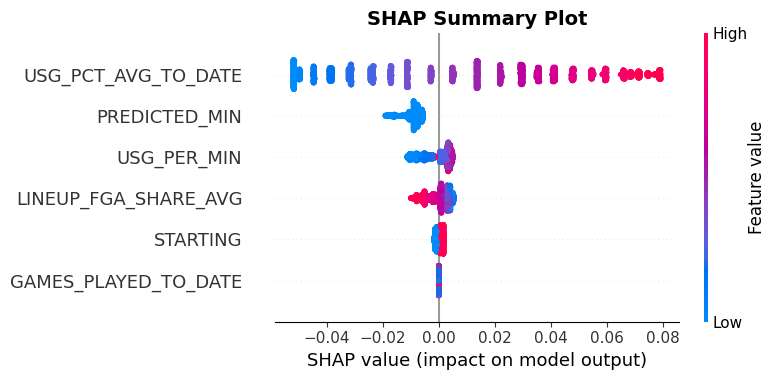

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.75
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [89]:
# analyze_shap(min_model, test_df, MIN_features, target_col='MIN')
analyze_shap(usg_model, test_df, USG_features, target_col='USG_PCT')
# analyze_shap(pts_model, test_df, PTS_features, target_col='PTS')